In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install scikit-learn matplotlib joblib -q


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import json
import time
import joblib
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from pathlib import Path
from scipy import sparse

# Traditional ML models
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    classification_report,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Đường dẫn
DRIVE_ROOT  = Path('/content/drive/MyDrive/amazon_clothing')
MODELS_DIR  = DRIVE_ROOT / 'outputs' / 'models'
FIGURES_DIR = DRIVE_ROOT / 'outputs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Label names để hiển thị
LABEL_NAMES = ['negative', 'neutral', 'positive']

print(' Import xong!')
print(f'   Models dir : {MODELS_DIR}')
print(f'   Figures dir: {FIGURES_DIR}')

 Import xong!
   Models dir : /content/drive/MyDrive/amazon_clothing/outputs/models
   Figures dir: /content/drive/MyDrive/amazon_clothing/outputs/figures


Load Feature Matrix

In [ ]:

X_train = sparse.load_npz(str(MODELS_DIR / 'review_features_train.npz'))
X_test  = sparse.load_npz(str(MODELS_DIR / 'review_features_test.npz'))
y_train = np.load(str(MODELS_DIR / 'review_labels_train.npy'))
y_test  = np.load(str(MODELS_DIR / 'review_labels_test.npy'))

print(f'\n   X_train shape: {X_train.shape}')
print(f'   X_test  shape: {X_test.shape}')
print(f'   y_train shape: {y_train.shape}')
print(f'   y_test  shape: {y_test.shape}')

print(f'\nPhân bố nhãn train:')
for i, name in enumerate(LABEL_NAMES):
    cnt = (y_train == i).sum()
    print(f'   {name:10}: {cnt:>8,} ({cnt/len(y_train)*100:.1f}%)')

print(f'\nPhân bố nhãn test:')
for i, name in enumerate(LABEL_NAMES):
    cnt = (y_test == i).sum()
    print(f'   {name:10}: {cnt:>8,} ({cnt/len(y_test)*100:.1f}%)')


   X_train shape: (2488797, 262144)
   X_test  shape: (630290, 262144)
   y_train shape: (2488797,)
   y_test  shape: (630290,)

Phân bố nhãn train:
   negative  :  345,882 (13.9%)
   neutral   :  210,728 (8.5%)
   positive  : 1,932,187 (77.6%)

Phân bố nhãn test:
   negative  :  109,971 (17.4%)
   neutral   :   57,060 (9.1%)
   positive  :  463,259 (73.5%)


Hàm Train & Evaluate

In [ ]:
import threading
import time

all_results = {}

def _print_timer(stop_event, model_name):
    t0 = time.time()
    while not stop_event.is_set():
        time.sleep(30)
        if stop_event.is_set():
            break
        elapsed = time.time() - t0
        mins    = int(elapsed // 60)
        secs    = int(elapsed % 60)
        print(f' [{model_name}] Đang train: {mins:02d}:{secs:02d}...', flush=True)

def train_and_evaluate(model, model_name, X_train, y_train, X_test, y_test):


    stop_event   = threading.Event()
    timer_thread = threading.Thread(
        target=_print_timer,
        args=(stop_event, model_name),
        daemon=True
    )
    timer_thread.start()

    t0         = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    stop_event.set()
    timer_thread.join()

    mins = int(train_time // 60)
    secs = int(train_time % 60)
    print(f'  Train xong {mins:02d}:{secs:02d} ({train_time:.1f}s)')

    print(f'Predicting')
    t1        = time.time()
    y_pred    = model.predict(X_test)
    pred_time = time.time() - t1
    f1_macro     = f1_score(y_test, y_pred, average='macro')
    f1_weighted  = f1_score(y_test, y_pred, average='weighted')
    f1_per_class = f1_score(y_test, y_pred, average=None)

    print(f'\nKết quả:')
    print(f'   F1 Macro   : {f1_macro:.4f}')
    print(f'   F1 Weighted: {f1_weighted:.4f}')
    print(f'\n   F1 từng class:')
    for name, f1 in zip(LABEL_NAMES, f1_per_class):
        bar = '█' * int(f1 * 20)
        print(f'   {name:10}: {bar:<20} {f1:.4f}')

    print(f'\n   Classification Report:')
    print(classification_report(y_test, y_pred, target_names=LABEL_NAMES))

    #  CONFUSION MATRIX
    cm   = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(7, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=LABEL_NAMES)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix — {model_name}', fontweight='bold')
    plt.tight_layout()
    save_path = FIGURES_DIR / f'step5_cm_{model_name.replace(" ","_").lower()}.png'
    plt.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.show()

    #  LƯU KẾT QUẢ
    result = {
        'model'         : model_name,
        'train_time_s'  : round(train_time, 1),
        'train_time_fmt': f'{mins:02d}:{secs:02d}',
        'f1_macro'      : round(f1_macro, 4),
        'f1_weighted'   : round(f1_weighted, 4),
        'f1_negative'   : round(f1_per_class[0], 4),
        'f1_neutral'    : round(f1_per_class[1], 4),
        'f1_positive'   : round(f1_per_class[2], 4),
    }
    all_results[model_name] = result

    model_path = MODELS_DIR / f'sentiment_{model_name.replace(" ","_").lower()}.joblib'
    joblib.dump(model, model_path)
    print(f'Saved: {model_path.name}')

    return result


Model : SGD Classifier

 [SGD Classifier] Đang train: 00:30...
  Train xong 00:32 (32.1s)
Predicting

Kết quả:
   F1 Macro   : 0.6387
   F1 Weighted: 0.8201

   F1 từng class:
   negative  : █████████████        0.6989
   neutral   : ██████               0.3047
   positive  : ██████████████████   0.9124

   Classification Report:
              precision    recall  f1-score   support

    negative       0.66      0.74      0.70    109971
     neutral       0.32      0.29      0.30     57060
    positive       0.92      0.90      0.91    463259

    accuracy                           0.82    630290
   macro avg       0.63      0.65      0.64    630290
weighted avg       0.82      0.82      0.82    630290



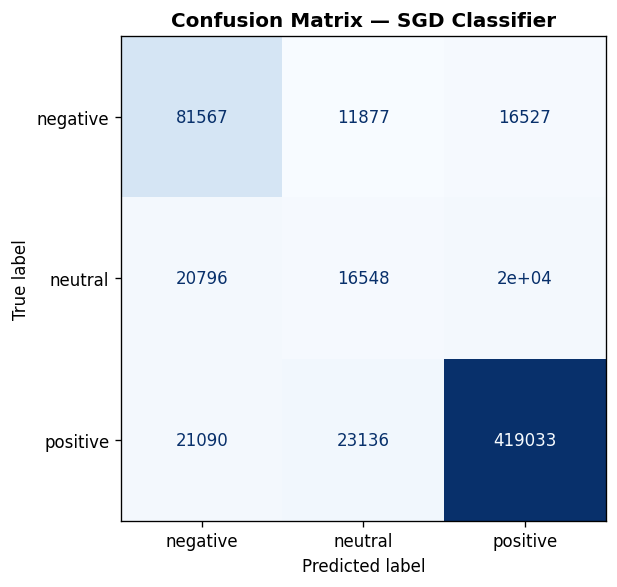

Saved: sentiment_sgd_classifier.joblib


In [ ]:
sgd_model = SGDClassifier(
    loss         = 'modified_huber',
    alpha        = 1e-4,
    max_iter     = 100,
    class_weight = 'balanced',
    random_state = 42,
    n_jobs       = -1
)

sgd_result = train_and_evaluate(
    sgd_model, 'SGD Classifier',
    X_train, y_train, X_test, y_test
)

Model : Linear SVM

 [Linear SVM] Đang train: 00:30...
 [Linear SVM] Đang train: 01:00...
 [Linear SVM] Đang train: 01:30...
 [Linear SVM] Đang train: 02:00...
 [Linear SVM] Đang train: 02:30...
 [Linear SVM] Đang train: 03:00...
 [Linear SVM] Đang train: 03:30...
 [Linear SVM] Đang train: 04:00...
 [Linear SVM] Đang train: 04:30...
 [Linear SVM] Đang train: 05:00...
 [Linear SVM] Đang train: 05:30...
 [Linear SVM] Đang train: 06:00...
 [Linear SVM] Đang train: 06:30...
 [Linear SVM] Đang train: 07:00...
 [Linear SVM] Đang train: 07:30...
 [Linear SVM] Đang train: 08:00...
 [Linear SVM] Đang train: 08:30...
 [Linear SVM] Đang train: 09:00...
 [Linear SVM] Đang train: 09:30...
 [Linear SVM] Đang train: 10:00...
 [Linear SVM] Đang train: 10:30...
 [Linear SVM] Đang train: 11:00...
 [Linear SVM] Đang train: 11:30...
 [Linear SVM] Đang train: 12:00...
 [Linear SVM] Đang train: 12:30...
 [Linear SVM] Đang train: 13:00...
 [Linear SVM] Đang train: 13:30...
 [Linear SVM] Đang train: 14:00...
 [Linear SVM] Đang t

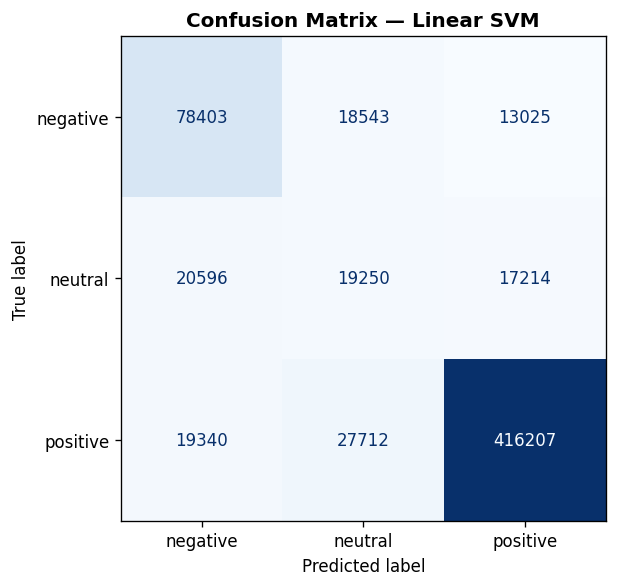

Saved: sentiment_linear_svm.joblib


In [ ]:
svm_model = LinearSVC(
    C            = 1.0,
    max_iter     = 2000,
    class_weight = 'balanced',
    random_state = 42
)

svm_result = train_and_evaluate(
    svm_model, 'Linear SVM',
    X_train, y_train, X_test, y_test
)

So sánh tất cả model

              model  f1_macro  f1_weighted  f1_negative  f1_neutral  f1_positive  train_time_s
     SGD Classifier    0.6387       0.8201       0.6989      0.3047       0.9124             0
         Linear SVM    0.6387       0.8208       0.6868      0.3141       0.9150             0
      Random Forest    0.5908       0.7622       0.6354      0.2860       0.8510             0
Logistic Regression    0.5472       0.7008       0.5673      0.2913       0.7830             0


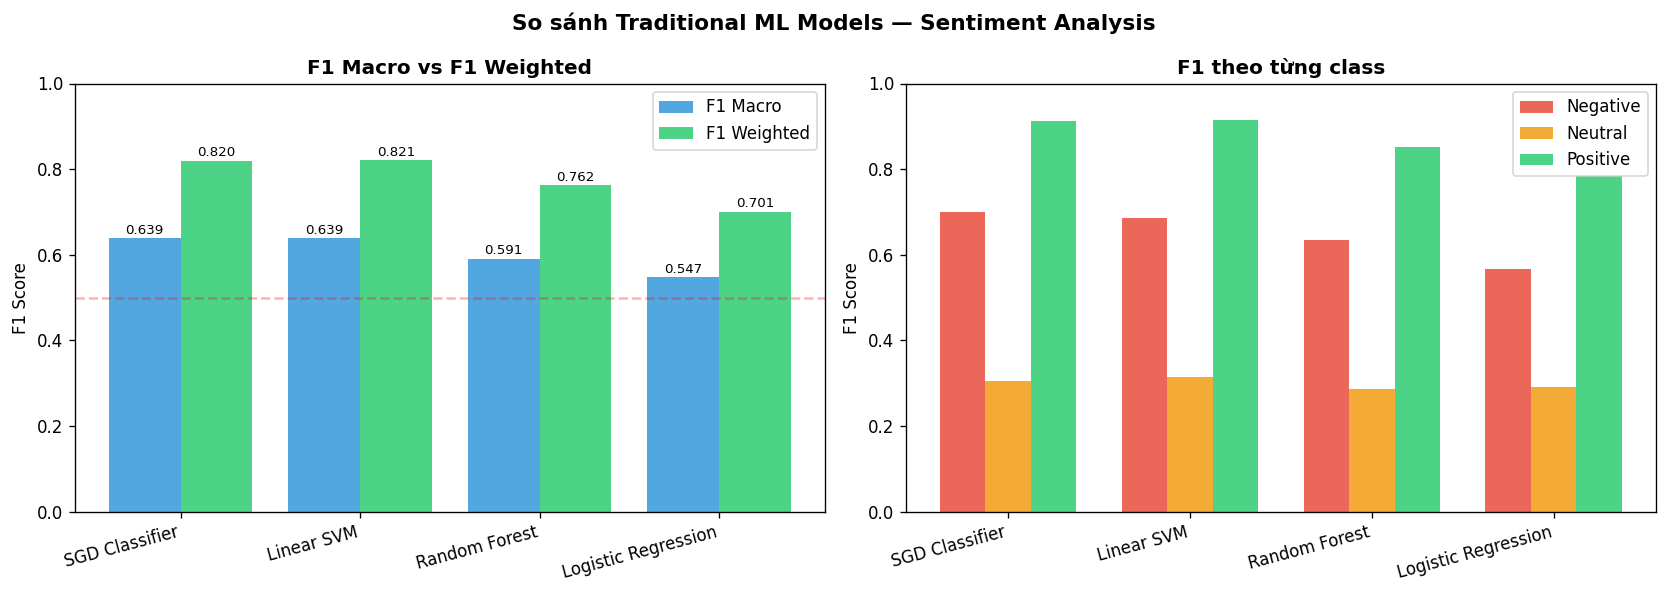


 Model tốt nhất: SGD Classifier
   F1 Macro   : 0.6387
   F1 Weighted: 0.8201

 Saved: sentiment_traditional_results.json


In [ ]:
import pandas as pd

# Tạo DataFrame kết quả
df_results = pd.DataFrame(list(all_results.values()))
df_results = df_results.sort_values('f1_macro', ascending=False)

print(df_results[['model','f1_macro','f1_weighted',
                   'f1_negative','f1_neutral','f1_positive',
                   'train_time_s']].to_string(index=False))

#  F1-macro và F1-weighted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('So sánh Traditional ML Models — Sentiment Analysis',
              fontsize=13, fontweight='bold')

models = df_results['model'].tolist()
x      = range(len(models))

# F1 scores
axes[0].bar([i - 0.2 for i in x], df_results['f1_macro'],
             width=0.4, label='F1 Macro', color='#3498db', alpha=0.85)
axes[0].bar([i + 0.2 for i in x], df_results['f1_weighted'],
             width=0.4, label='F1 Weighted', color='#2ecc71', alpha=0.85)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(models, rotation=15, ha='right')
axes[0].set_ylabel('F1 Score')
axes[0].set_ylim(0, 1.0)
axes[0].set_title('F1 Macro vs F1 Weighted', fontweight='bold')
axes[0].legend()
axes[0].axhline(0.5, color='red', linestyle='--', alpha=0.3, label='0.5 threshold')
for i, (macro, weighted) in enumerate(
    zip(df_results['f1_macro'], df_results['f1_weighted'])
):
    axes[0].text(i-0.2, macro+0.01, f'{macro:.3f}', ha='center', fontsize=8)
    axes[0].text(i+0.2, weighted+0.01, f'{weighted:.3f}', ha='center', fontsize=8)

# F1 theo từng class
width = 0.25
axes[1].bar([i - width for i in x], df_results['f1_negative'],
             width=width, label='Negative', color='#e74c3c', alpha=0.85)
axes[1].bar([i for i in x], df_results['f1_neutral'],
             width=width, label='Neutral', color='#f39c12', alpha=0.85)
axes[1].bar([i + width for i in x], df_results['f1_positive'],
             width=width, label='Positive', color='#2ecc71', alpha=0.85)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(models, rotation=15, ha='right')
axes[1].set_ylabel('F1 Score')
axes[1].set_ylim(0, 1.0)
axes[1].set_title('F1 theo từng class', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'step5_traditional_ml_comparison.png',
             dpi=130, bbox_inches='tight')
plt.show()

# Model tốt nhất
best = df_results.iloc[0]
print(f'\n Model tốt nhất: {best["model"]}')
print(f'   F1 Macro   : {best["f1_macro"]}')
print(f'   F1 Weighted: {best["f1_weighted"]}')

with open(MODELS_DIR / 'sentiment_traditional_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)
print(f'\n Saved: sentiment_traditional_results.json')